In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/datasets/ayaanaraza/eyetracking/Images'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS176_03.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS110_19.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS085_19.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS064_19.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS008_20.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS188_05.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS088_18.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS170_24.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS066_19.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS070_18.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS007_20.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS173_24.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS054_11.png
/kaggle/input/datasets/ay

In [ ]:

import os
import glob
import numpy as np
import cv2
#from keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.decomposition import PCA

In [3]:
img_dim = 100
aug_img_count = 3
cropped_dir_tc= '/kaggle/working/Dataset/TC/Cropped'
cropped_dir_ts = '/kaggle/working/Dataset/TS/Cropped'
aug_tc_dir = '/kaggle/working/Dataset/TC/Augmented'
aug_ts_dir = '/kaggle/working/Dataset/TS/Augmented'
output_npz = '/kaggle/working/ASD_combined.npz'
os.makedirs(cropped_dir_tc, exist_ok=True)
os.makedirs(cropped_dir_ts, exist_ok=True)
os.makedirs(aug_tc_dir, exist_ok=True)
os.makedirs(aug_ts_dir, exist_ok=True)

Starting full dataset augmentation...

 Category: TC | Original images: 328
 Augmented 984 images saved to: /kaggle/working/Dataset/TC/Augmented

 Category: TS | Original images: 219
 Augmented 657 images saved to: /kaggle/working/Dataset/TS/Augmented

 Displaying 1 original + 2 augmented samples per category...


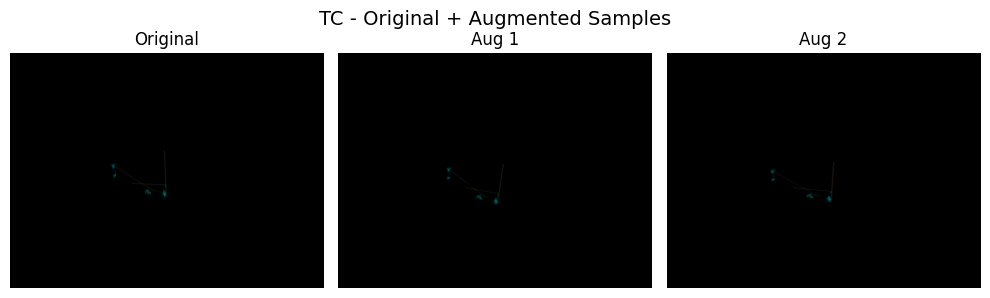

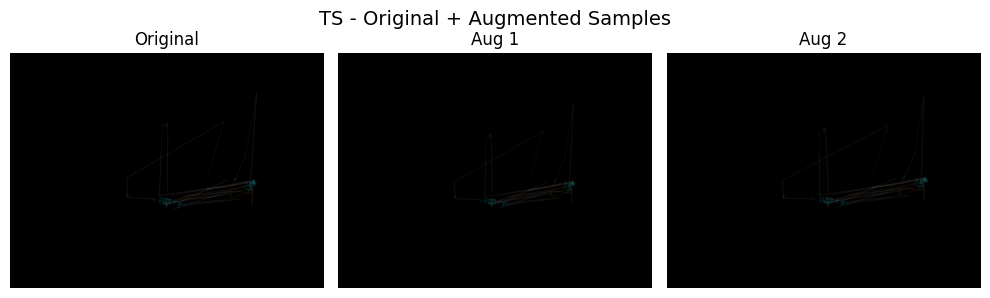

In [5]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# ============ STEP 1: IMAGE AUGMENTATION ============
print("Starting full dataset augmentation...")

# Setup augmenter
augmenter = ImageDataGenerator(rotation_range=10, shear_range=0.2, zoom_range=0.2, fill_mode='nearest')

# Define original and augmented image directories
categories = {
    'TC': '/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TCImages',
    'TS': '/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages'
}

# Update with your actual output folders for augmented images
aug_tc_dir = '/kaggle/working/Dataset/TC/Augmented'
aug_ts_dir = '/kaggle/working/Dataset/TS/Augmented'
os.makedirs(aug_tc_dir, exist_ok=True)
os.makedirs(aug_ts_dir, exist_ok=True)

# Number of augmented images to generate per original image
aug_img_count = 3

# Augment and save for all images
for category, folder in categories.items():
    save_dir = aug_tc_dir if category == 'TC' else aug_ts_dir
    image_paths = glob.glob(os.path.join(folder, '*.png'))
    print(f"\n Category: {category} | Original images: {len(image_paths)}")

    for file in image_paths:
        img = load_img(file)
        img_array = img_to_array(img)
        img_array = img_array.reshape((1,) + img_array.shape)
        base_name = os.path.splitext(os.path.basename(file))[0]
        count = 0
        for batch in augmenter.flow(img_array, batch_size=1, save_to_dir=save_dir,
                                   save_prefix=base_name + '_aug', save_format='png'):
            count += 1
            # Save the augmented images with the number appended
            if count == aug_img_count:
                break

    print(f" Augmented {aug_img_count * len(image_paths)} images saved to: {save_dir}")

# ============ STEP 2: SHOW ONE ORIGINAL + TWO AUGMENTED SAMPLES ============
print("\n Displaying 1 original + 2 augmented samples per category...")

preview_aug_count = 2  # Number of augmentations to preview

for category, folder in categories.items():
    image_paths = glob.glob(os.path.join(categories[category], '*.png'))
    if not image_paths:
        continue

    # Pick the first image
    img_path = image_paths[0]
    img = load_img(img_path)
    img_array = img_to_array(img).astype('uint8')
    img_array = img_array.reshape((1,) + img_array.shape)

    plt.figure(figsize=(10, 3))
    plt.subplot(1, preview_aug_count + 1, 1)
    plt.imshow(img_array[0].astype('uint8') / 255.0)
    plt.title("Original")
    plt.axis("off")

    for i, batch in enumerate(augmenter.flow(img_array, batch_size=1)):
        aug_img = batch[0].astype('uint8')
        # Add the augmentation number to the title
        plt.subplot(1, preview_aug_count + 1, i + 2)
        plt.imshow(aug_img / 255.0)
        plt.title(f'Aug {i+1}')
        plt.axis('off')
        if i + 1 == preview_aug_count:
            break

    plt.suptitle(f"{category} - Original + Augmented Samples", fontsize=14)
    plt.tight_layout()
    plt.show()


In [ ]:
aug_tc_images = glob.glob('/kaggle/working/Dataset/TC/Augmented/*.png')
aug_ts_images = glob.glob('/kaggle/working/Dataset/TS/Augmented/*.png')
print(f"TC Augmented: {len(aug_tc_images)} | TS: {len(aug_ts_images)}")

TC Augmented: 984 | TS: 657


In [ ]:
aug_tc_images = glob.glob('/kaggle/working/Dataset/TC/Augmented/*.[Pp][Nn][Gg]')
aug_ts_images = glob.glob('/kaggle/working/Dataset/TS/Augmented/*.[Pp][Nn][Gg]')
print(f"TC Augmented: {len(aug_tc_images)} | TS: {len(aug_ts_images)}")

print("First 5 TC Augmented Images:", aug_tc_images[:5])
print("First 5 TS Augmented Images:", aug_ts_images[:5])


TC Augmented: 984 | TS: 657
First 5 TC Augmented Images: ['/kaggle/working/Dataset/TC/Augmented/TC297_46_aug_0_6885.png', '/kaggle/working/Dataset/TC/Augmented/TC040_39_aug_0_4036.png', '/kaggle/working/Dataset/TC/Augmented/TC246_53_aug_0_8848.png', '/kaggle/working/Dataset/TC/Augmented/TC163_39_aug_0_1570.png', '/kaggle/working/Dataset/TC/Augmented/TC113_33_aug_0_224.png']
First 5 TS Augmented Images: ['/kaggle/working/Dataset/TS/Augmented/TS148_10_aug_0_6113.png', '/kaggle/working/Dataset/TS/Augmented/TS008_20_aug_0_9852.png', '/kaggle/working/Dataset/TS/Augmented/TS179_03_aug_0_1322.png', '/kaggle/working/Dataset/TS/Augmented/TS171_24_aug_0_552.png', '/kaggle/working/Dataset/TS/Augmented/TS137_06_aug_0_6750.png']


 Cropping augmented images and previewing...


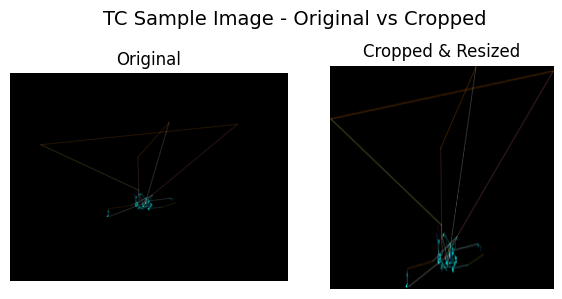

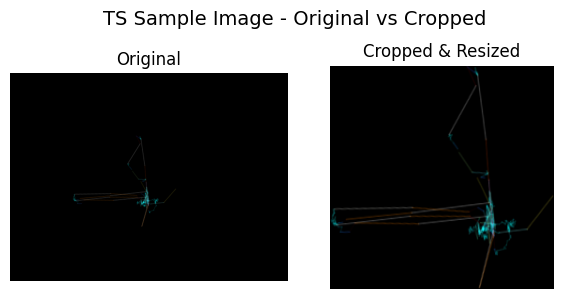


 Total Cropped Images:
   TC: 984
   TS: 657


In [ ]:
import os
import glob
import cv2
import matplotlib.pyplot as plt

print(" Cropping augmented images and previewing...")

# Input folders
augmented_folders = [
    '/kaggle/working/Dataset/TC/Augmented',
    '/kaggle/working/Dataset/TS/Augmented'
]

# Output folders
cropped_dir_tc = '/kaggle/working/Dataset/TC/Cropped'
cropped_dir_ts = '/kaggle/working/Dataset/TS/Cropped'
os.makedirs(cropped_dir_tc, exist_ok=True)
os.makedirs(cropped_dir_ts, exist_ok=True)

# Counters and preview flags
tc_count = 0
ts_count = 0
tc_preview_shown = False
ts_preview_shown = False

# Process images
for folder in augmented_folders:
    for img_file in glob.iglob(os.path.join(folder, '**/*.png'), recursive=True):
        img = cv2.imread(img_file)
        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        _, threshed = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(threshed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if contours:
            cnt = max(contours, key=cv2.contourArea)
            x, y, w, h = cv2.boundingRect(cnt)
            cropped = img[y:y + h, x:x + w]
            resized = cv2.resize(cropped, (224, 224))

            # Decide category
            if 'TC' in folder:
                target_dir = cropped_dir_tc
                tc_count += 1
                preview_flag = not tc_preview_shown
                tc_preview_shown = True
            else:
                target_dir = cropped_dir_ts
                ts_count += 1
                preview_flag = not ts_preview_shown
                ts_preview_shown = True

            # Save
            img_id = os.path.basename(img_file).rsplit('.', 1)[0]
            save_path = os.path.join(target_dir, img_id + '.jpg')
            cv2.imwrite(save_path, resized, [int(cv2.IMWRITE_JPEG_QUALITY), 100])

            # Show one preview image per category
            if preview_flag:
                plt.figure(figsize=(6, 3))
                plt.subplot(1, 2, 1)
                plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                plt.title("Original")
                plt.axis("off")

                plt.subplot(1, 2, 2)
                plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
                plt.title("Cropped & Resized")
                plt.axis("off")

                cat = 'TC' if 'TC' in folder else 'TS'
                plt.suptitle(f"{cat} Sample Image - Original vs Cropped", fontsize=14)
                plt.tight_layout()
                plt.show()

# Print final counts
print(f"\n Total Cropped Images:")
print(f"   TC: {tc_count}")
print(f"   TS: {ts_count}")


In [8]:
aug_tc_images = glob.glob('/kaggle/working/Dataset/TC/Augmented/*.png')
crop_tc_images = glob.glob('/kaggle/working/Dataset/TC/Cropped/*.jpg')

print(f"TC Augmented: {len(aug_tc_images)} | TC Cropped: {len(crop_tc_images)}")

aug_ts_images = glob.glob('/kaggle/working/Dataset/TS/Augmented/*.png')
crop_ts_images = glob.glob('/kaggle/working/Dataset/TS/Cropped/*.jpg')

print(f"TC Augmented: {len(aug_ts_images)} | TC Cropped: {len(crop_ts_images)}")

TC Augmented: 983 | TC Cropped: 0
TC Augmented: 657 | TC Cropped: 0


In [ ]:
import os
for dirname, _, filenames in os.walk('/kaggle/working'):
    if filenames:  # Only print folders that contain files
        print(dirname)

/kaggle/working/Dataset/TS/Augmented
/kaggle/working/Dataset/TS/Cropped
/kaggle/working/Dataset/TC/Augmented
/kaggle/working/Dataset/TC/Cropped


## DenseNet


In [ ]:
import numpy as np
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, AveragePooling2D,MaxPooling2D
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score
#from scipy import interp
import matplotlib.pyplot as plt
import time

In [ ]:
import os
import glob
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.densenet import preprocess_input  # DenseNet-specific preprocessing
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Step 1: Feature Extraction with DenseNet121
print("Starting feature extraction using DenseNet121...")

# DenseNet121 model setup
base_model = DenseNet121(weights='imagenet', include_top=False, pooling='avg')
feature_extractor = Model(inputs=base_model.input, outputs=base_model.output)

# Directories
cropped_dirs = {
    'TC': '/kaggle/working/Dataset/TC/Cropped',
    'TS': '/kaggle/working/Dataset/TS/Cropped'
}

features = []
labels = []

# Extract features from each image
for label, (cat, folder) in enumerate(cropped_dirs.items()):
    print(f" Extracting features for category: {cat}")
    image_paths = glob.glob(os.path.join(folder, '*.jpg'))

    for img_path in tqdm(image_paths):
        img = load_img(img_path, target_size=(224, 224))
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess_input(img_array)  # Apply DenseNet-specific preprocessing
        feature_vector = feature_extractor.predict(img_array, verbose=0)[0]
        features.append(feature_vector)
        labels.append(label)

# Convert to NumPy arrays
X = np.array(features)
y = np.array(labels)
print(f" Feature extraction complete! X shape: {X.shape}, y shape: {y.shape}")

# Step 2: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


Starting feature extraction using DenseNet121...
 Extracting features for category: TC


100%|██████████| 984/984 [01:22<00:00, 11.91it/s]


 Extracting features for category: TS


100%|██████████| 657/657 [00:46<00:00, 14.10it/s]

 Feature extraction complete! X shape: (1641, 1024), y shape: (1641,)



 Applying PCA to retain 99% variance...
Original shape: (1641, 1024)
Reduced shape: (1641, 306)
Number of features selected: 306


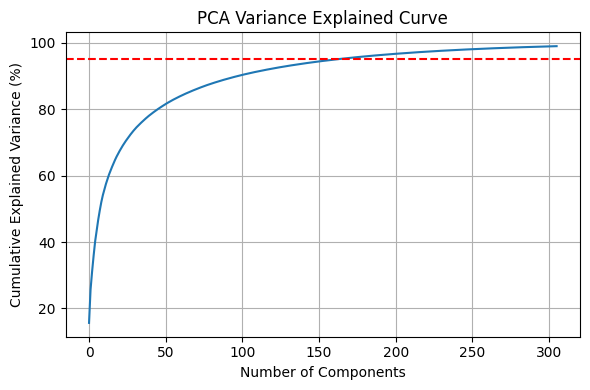

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Use PCA to retain 99% of the variance
print("\n Applying PCA to retain 99% variance...")

pca = PCA(n_components=0.99, random_state=42)
X_reduced = pca.fit_transform(X)

print(f"Original shape: {X.shape}")
print(f"Reduced shape: {X_reduced.shape}")
print(f"Number of features selected: {X_reduced.shape[1]}")

# Step 2 (optional): Plot cumulative explained variance
plt.figure(figsize=(6, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_) * 100)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA Variance Explained Curve')
plt.grid(True)
plt.axhline(y=95, color='r', linestyle='--')
plt.tight_layout()
plt.show()


In [ ]:
# Step 2: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)



#DNN no PCA


 Building and training classification model...
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6337 - loss: 0.6837 - val_accuracy: 0.7720 - val_loss: 0.4763
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7417 - loss: 0.5187 - val_accuracy: 0.7568 - val_loss: 0.4668
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7474 - loss: 0.5000 - val_accuracy: 0.7356 - val_loss: 0.4723
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7496 - loss: 0.4807 - val_accuracy: 0.7477 - val_loss: 0.4732
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7678 - loss: 0.4746 - val_accuracy: 0.7295 - val_loss: 0.4851
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7592 - loss: 0.4716 - val_accuracy: 0.7994 - val_loss: 0.4375
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7924 - loss: 0.4378 - val_accuracy: 0.7842 - val_loss: 0.4426
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7813 - loss: 0.4443 - val_accuracy: 0.7599 - val_loss: 0.

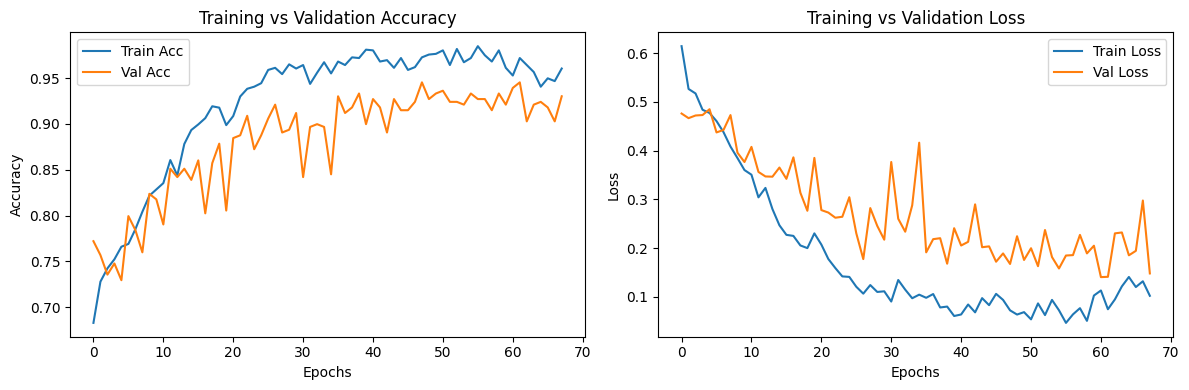


 Classification Report:
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
              precision    recall  f1-score   support

          TC    0.95431   0.95431   0.95431       197
          TS    0.93182   0.93182   0.93182       132

    accuracy                        0.94529       329
   macro avg    0.94307   0.94307   0.94307       329
weighted avg    0.94529   0.94529   0.94529       329



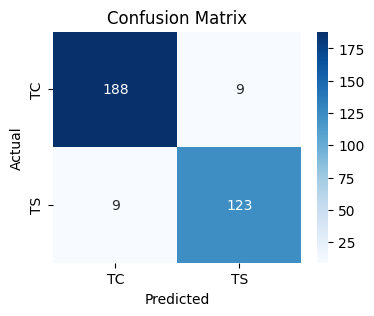

In [ ]:
# Step 3: Build and Train the Classification Model
print("\n Building and training classification model...")

classifier = Sequential([
    Dense(256, activation='relu', input_shape=(X.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # For binary classification: TC (0) vs TS (1)
])

classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True)

history = classifier.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Step 4: Plot Accuracy and Loss
plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Step 5: Evaluation
print("\n Classification Report:")
y_pred = (classifier.predict(X_test) > 0.5).astype("int32")
print(classification_report(y_test, y_pred, target_names=['TC', 'TS'], digits=5))

# Step 6: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['TC', 'TS'], yticklabels=['TC', 'TS'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


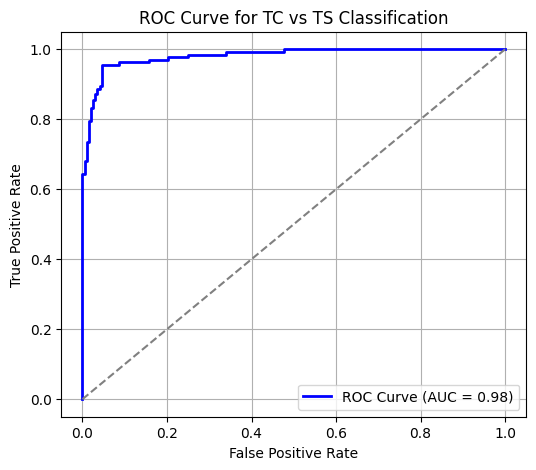

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Predict probabilities (not hard labels)
y_pred_probs = classifier.predict(X_test)

# ROC Curve and AUC Score
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = roc_auc_score(y_test, y_pred_probs)

# Plot the ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for TC vs TS Classification')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


#PCA DNN


 Building and training classification model with reduced features...
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6128 - loss: 0.6489 - val_accuracy: 0.7629 - val_loss: 0.4446
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8177 - loss: 0.4075 - val_accuracy: 0.8328 - val_loss: 0.3765
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8728 - loss: 0.3149 - val_accuracy: 0.8754 - val_loss: 0.3065
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9153 - loss: 0.2238 - val_accuracy: 0.8936 - val_loss: 0.2456
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9513 - loss: 0.1420 - val_accuracy: 0.9271 - val_loss: 0.1863
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9797 - loss: 0.0860 - val_accuracy: 0.9149 - val_loss: 0.1865
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9866 - loss: 0.0603 - val_accuracy: 0.9362 - val_loss: 0.1662
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9862 - loss: 0.0488 - val_accuracy: 0.9483 - val_loss: 0.

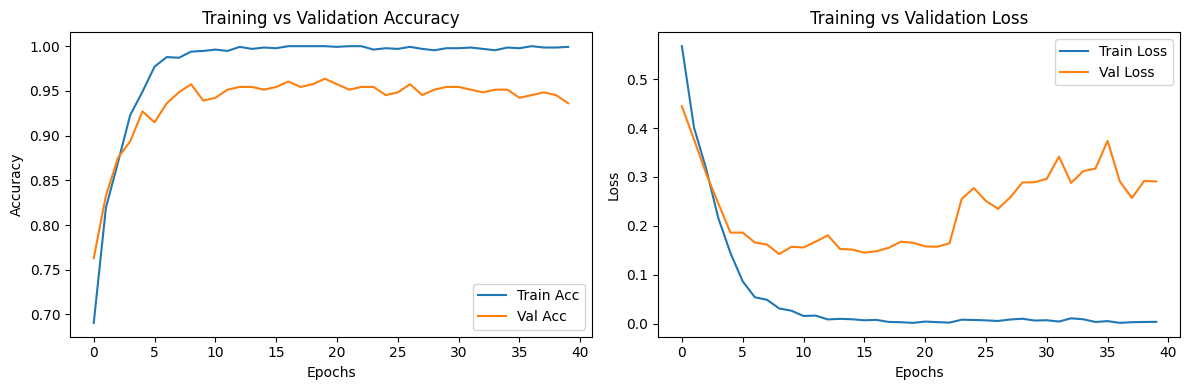


 Classification Report:
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
              precision    recall  f1-score   support

          TC    0.96954   0.96954   0.96954       197
          TS    0.95455   0.95455   0.95455       132

    accuracy                        0.96353       329
   macro avg    0.96204   0.96204   0.96204       329
weighted avg    0.96353   0.96353   0.96353       329



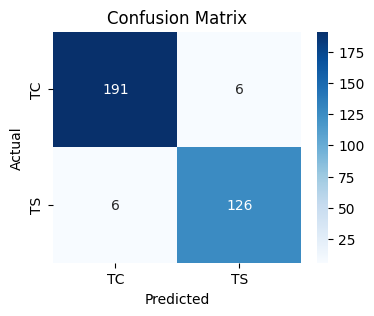

In [ ]:
# Step 3: Build and Train the Classification Model
print("\n Building and training classification model with reduced features...")
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, stratify=y, random_state=42
)
classifier = Sequential([
    Dense(256, activation='relu', input_shape=(X_reduced.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # For binary classification: TC (0) vs TS (1)
])

classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True)

history = classifier.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Step 4: Plot Accuracy and Loss
plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Step 5: Evaluation
print("\n Classification Report:")
y_pred = (classifier.predict(X_test) > 0.5).astype("int32")
print(classification_report(y_test, y_pred, target_names=['TC', 'TS'], digits=5))

# Step 6: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['TC', 'TS'], yticklabels=['TC', 'TS'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


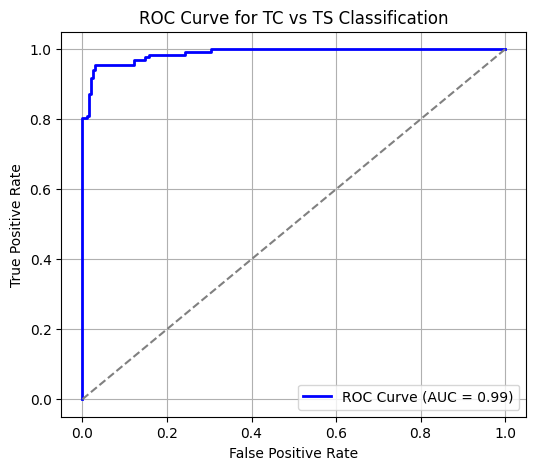

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Predict probabilities (not hard labels)
y_pred_probs = classifier.predict(X_test)

# ROC Curve and AUC Score
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = roc_auc_score(y_test, y_pred_probs)

# Plot the ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for TC vs TS Classification')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


#PCA ML



 Model: Random Forest
Accuracy: 0.8055
ROC AUC: 0.9230
Classification Report:
              precision    recall  f1-score   support

          TC       0.76      0.98      0.86       197
          TS       0.95      0.55      0.69       132

    accuracy                           0.81       329
   macro avg       0.86      0.76      0.78       329
weighted avg       0.84      0.81      0.79       329


 Model: Extra Trees
Accuracy: 0.8328
ROC AUC: 0.9547
Classification Report:
              precision    recall  f1-score   support

          TC       0.78      0.99      0.88       197
          TS       0.99      0.59      0.74       132

    accuracy                           0.83       329
   macro avg       0.89      0.79      0.81       329
weighted avg       0.87      0.83      0.82       329


 Model: AdaBoost
Accuracy: 0.7812
ROC AUC: 0.8652
Classification Report:
              precision    recall  f1-score   support

          TC       0.81      0.82      0.82       197
       

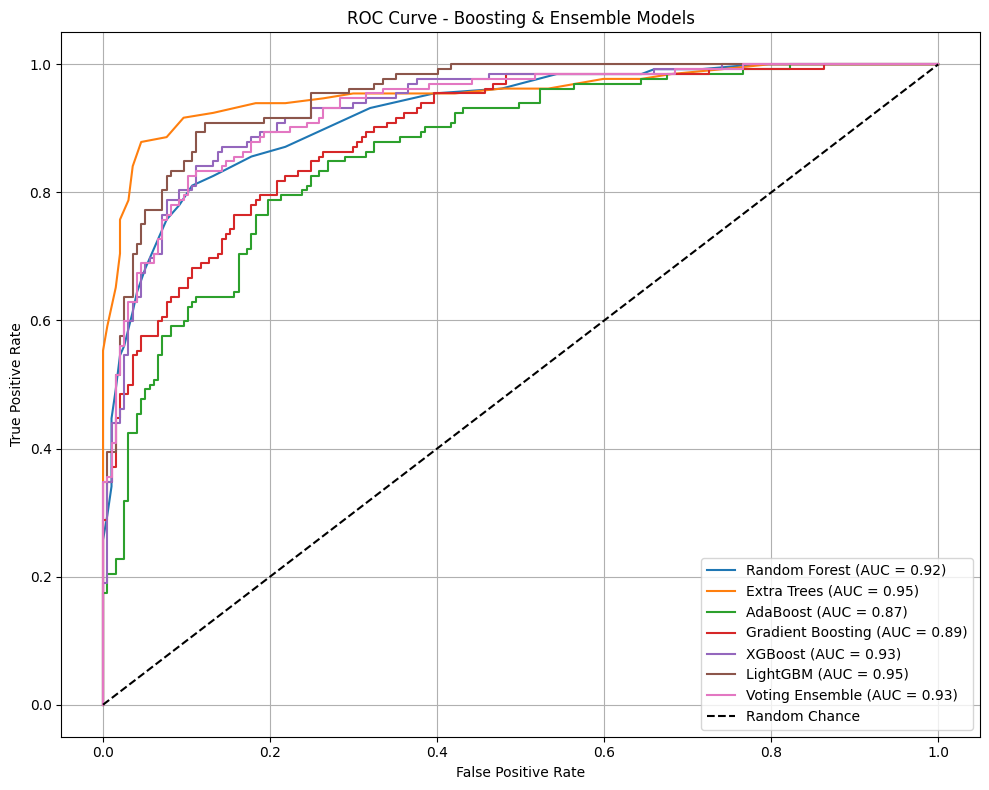

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, ExtraTreesClassifier, VotingClassifier
)
from sklearn.metrics import (
    classification_report, accuracy_score,
    roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# === ASSUME features and labels already loaded as X_features, y_labels ===

# Train/test split
#X_train, X_test, y_train, y_test = train_test_split(X_pca, y_labels, test_size=0.2, random_state=42)

# === MODELS ===
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42),
}

# Add a Voting Classifier (Ensemble)
models["Voting Ensemble"] = VotingClassifier(
    estimators=[
        ('rf', models["Random Forest"]),
        ('gb', models["Gradient Boosting"]),
        ('xgb', models["XGBoost"])
    ],
    voting='soft'
)

# === EVALUATION ===
plt.figure(figsize=(10, 8))
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=["TC", "TS"])
    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # Print performance
    print(f"\n Model: {name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"ROC AUC: {auc:.4f}")
    print("Classification Report:")
    print(report)

    # Plot ROC
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

# === ROC Curve Final Plot ===
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Boosting & Ensemble Models')
plt.legend(loc='lower right')
plt.grid()
plt.tight_layout()
plt.show()


#ML No PCA



 Model: Random Forest
Accuracy: 0.8754
ROC AUC: 0.9524
Classification Report:
              precision    recall  f1-score   support

          TC       0.85      0.95      0.90       197
          TS       0.92      0.76      0.83       132

    accuracy                           0.88       329
   macro avg       0.89      0.86      0.87       329
weighted avg       0.88      0.88      0.87       329


 Model: Extra Trees
Accuracy: 0.9240
ROC AUC: 0.9784
Classification Report:
              precision    recall  f1-score   support

          TC       0.91      0.97      0.94       197
          TS       0.96      0.85      0.90       132

    accuracy                           0.92       329
   macro avg       0.93      0.91      0.92       329
weighted avg       0.93      0.92      0.92       329


 Model: AdaBoost
Accuracy: 0.7964
ROC AUC: 0.8806
Classification Report:
              precision    recall  f1-score   support

          TC       0.81      0.86      0.83       197
       

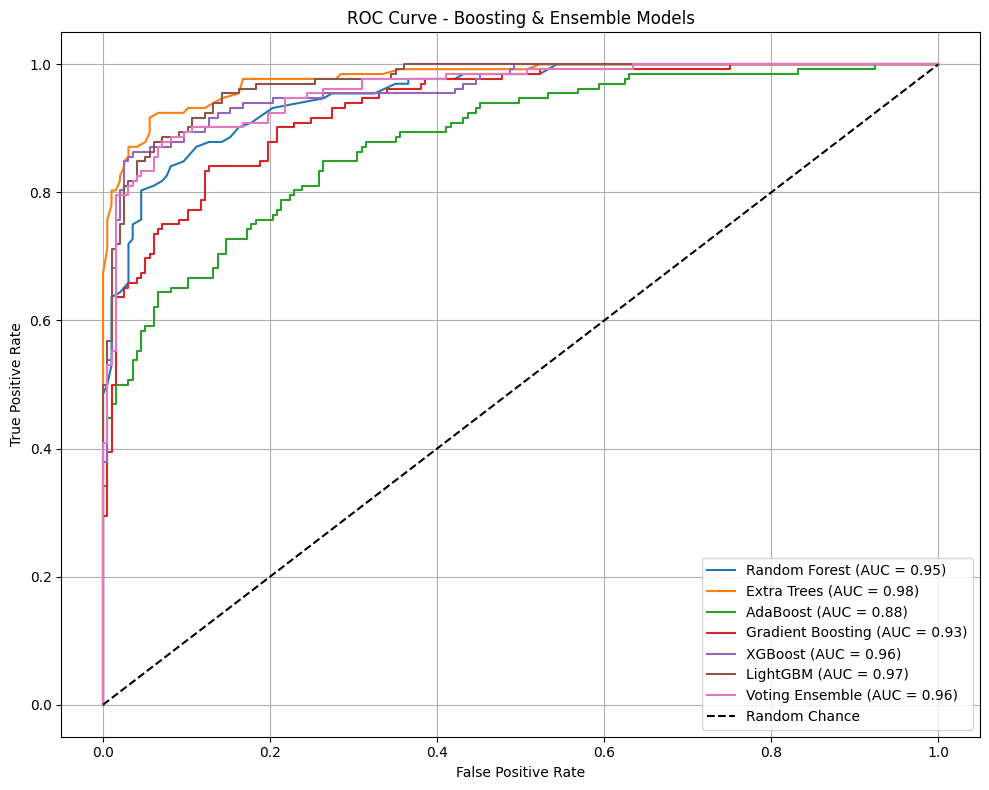

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, ExtraTreesClassifier, VotingClassifier
)
from sklearn.metrics import (
    classification_report, accuracy_score,
    roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier



# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# === MODELS ===
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42),
}

# Add a Voting Classifier (Ensemble)
models["Voting Ensemble"] = VotingClassifier(
    estimators=[
        ('rf', models["Random Forest"]),
        ('gb', models["Gradient Boosting"]),
        ('xgb', models["XGBoost"])
    ],
    voting='soft'
)

# === EVALUATION ===
plt.figure(figsize=(10, 8))
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=["TC", "TS"])
    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # Print performance
    print(f"\n Model: {name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"ROC AUC: {auc:.4f}")
    print("Classification Report:")
    print(report)

    # Plot ROC
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

# === ROC Curve Final Plot ===
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Boosting & Ensemble Models')
plt.legend(loc='lower right')
plt.grid()
plt.tight_layout()
plt.show()


## DenseNet121

In [ ]:
def load_images(folder, label):
    images, labels = [], []
    for path in glob.glob(os.path.join(folder, '*.jpg')):
        img = load_img(path, target_size=(224, 224))
        img = img_to_array(img)
        img = preprocess_input(img)
        images.append(img)
        labels.append(label)
    return images, labels

# Load from your cropped folders
tc_imgs, tc_labels = load_images('/kaggle/working/Dataset/TC/Cropped', 0)
ts_imgs, ts_labels = load_images('/kaggle/working/Dataset/TS/Cropped', 1)

X = np.array(tc_imgs + ts_imgs)
y = np.array(tc_labels + ts_labels)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


#Direct

In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Load DenseNet121 base (freeze early layers to avoid overfitting)
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Fine-tune last layers
for layer in base_model.layers[:300]:
    layer.trainable = False
for layer in base_model.layers[300:]:
    layer.trainable = True

# Add custom classification head
x = GlobalAveragePooling2D()(base_model.output)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)  # Binary classification

# Define model
model = Model(inputs=base_model.input, outputs=output)

# Learning rate schedule
lr_schedule = ExponentialDecay(
    initial_learning_rate=1e-4,
    decay_steps=1000,
    decay_rate=0.9
)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=lr_schedule),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True)

# Train model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=16,  # Smaller batch size for generalization
    callbacks=[early_stop, checkpoint],
    verbose=1
)


Epoch 1/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 86s 282ms/step - accuracy: 0.6482 - loss: 0.7000 - val_accuracy: 0.7538 - val_loss: 0.5189
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.7727 - loss: 0.4876 - val_accuracy: 0.8663 - val_loss: 0.3700
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.8444 - loss: 0.3267 - val_accuracy: 0.9179 - val_loss: 0.2673
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.9139 - loss: 0.2116 - val_accuracy: 0.9271 - val_loss: 0.2131
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.9426 - loss: 0.1560 - val_accuracy: 0.9331 - val_loss: 0.1658
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.9629 - loss: 0.1151 - val_accuracy: 0.9392 - val_loss: 0.1459
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.9773 - loss: 0.0858 - val_accuracy: 0.9666 - val_loss: 0.1086
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.9806 - loss: 0.0629 - val_accuracy: 

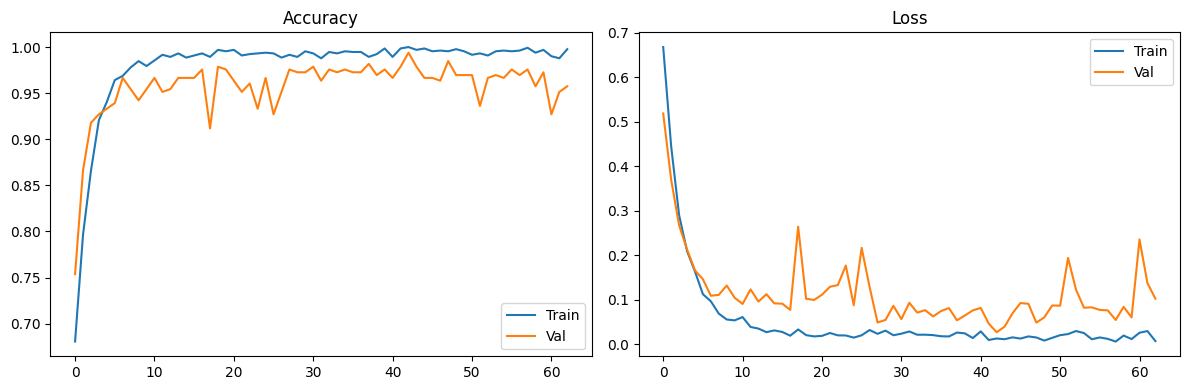

11/11 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step
Classification Report:
               precision    recall  f1-score   support

          TC    0.99492   0.99492   0.99492       197
          TS    0.99242   0.99242   0.99242       132

    accuracy                        0.99392       329
   macro avg    0.99367   0.99367   0.99367       329
weighted avg    0.99392   0.99392   0.99392       329



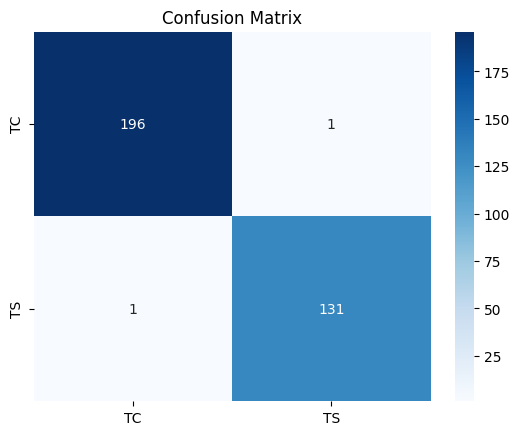

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Accuracy"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("Loss"); plt.legend()
plt.tight_layout()
plt.show()

y_pred = (model.predict(X_test) > 0.5).astype('int32')
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=['TC', 'TS'], digits=5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['TC', 'TS'], yticklabels=['TC', 'TS'])
plt.title("Confusion Matrix")
plt.show()


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


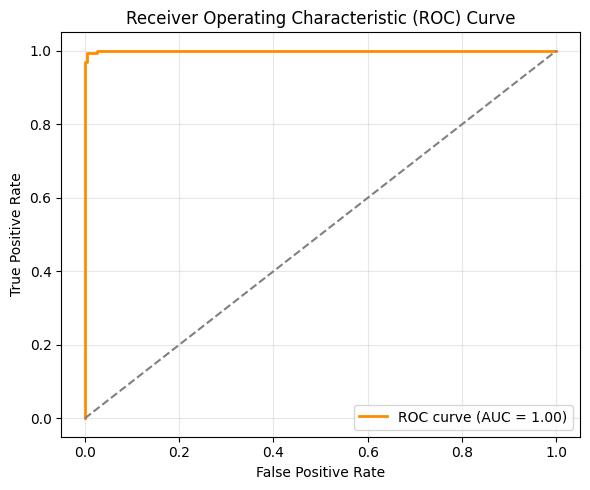

In [ ]:
# Get predicted probabilities
y_pred_prob = model.predict(X_test).ravel()

# Compute ROC metrics
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import tensorflow as tf

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0].numpy()
    pooled_grads = pooled_grads.numpy()

    for i in range(pooled_grads.shape[-1]):
        conv_outputs[:, :, i] *= pooled_grads[i]

    heatmap = np.mean(conv_outputs, axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= (np.max(heatmap) + 1e-8)

    return heatmap

In [ ]:
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def display_gradcam_batch(X_data, y_data, model, num_samples=5, last_conv_layer='conv5_block16_2_conv'):
    indices = random.sample(range(len(X_data)), num_samples)

    for idx in indices:
        img = X_data[idx]
        label = y_data[idx]
        img_input = np.expand_dims(img, axis=0)  # Add batch dimension

        # Generate Grad-CAM heatmap
        heatmap = make_gradcam_heatmap(img_input, model, last_conv_layer)

        # Reconstruct original image (if necessary for your preprocessing)
        orig = img.copy()
        orig = orig[..., ::-1]  # Convert from BGR to RGB if needed (if image is in BGR format)
        orig += [123.68, 116.779, 103.939]  # Reverse the DenseNet mean subtraction (RGB order now)
        orig = np.clip(orig, 0, 255).astype('uint8')

        # Resize and overlay heatmap
        heatmap_resized = cv2.resize(heatmap, (orig.shape[1], orig.shape[0]))
        heatmap_vis = np.uint8(255 * heatmap_resized)
        overlay = cv2.applyColorMap(heatmap_vis, cv2.COLORMAP_JET)
        overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)  # Convert to RGB for display
        superimposed = cv2.addWeighted(orig, 0.6, overlay, 0.4, 0)

        # Model prediction
        pred = model.predict(img_input)[0]  # Model prediction (assumes binary classification)

        # Predict class
        pred_class = 'TS' if pred >= 0.5 else 'TC'
        actual_class = 'TS' if label == 1 else 'TC'

        # Plotting
        plt.figure(figsize=(12, 4))
        #plt.suptitle(f"True: {actual_class} | Pred: {pred_class} ({pred:.2f})", fontsize=14)
        plt.suptitle(f"True: {actual_class} | Pred: {pred_class} ({pred[0]:.2f})", fontsize=14)


        plt.subplot(1, 3, 1)
        plt.imshow(orig)
        plt.title("Original")
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.imshow(heatmap_resized, cmap='jet')
        plt.title("Heatmap")
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.imshow(superimposed)
        plt.title("Overlay")
        plt.axis('off')

        plt.tight_layout()
        plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


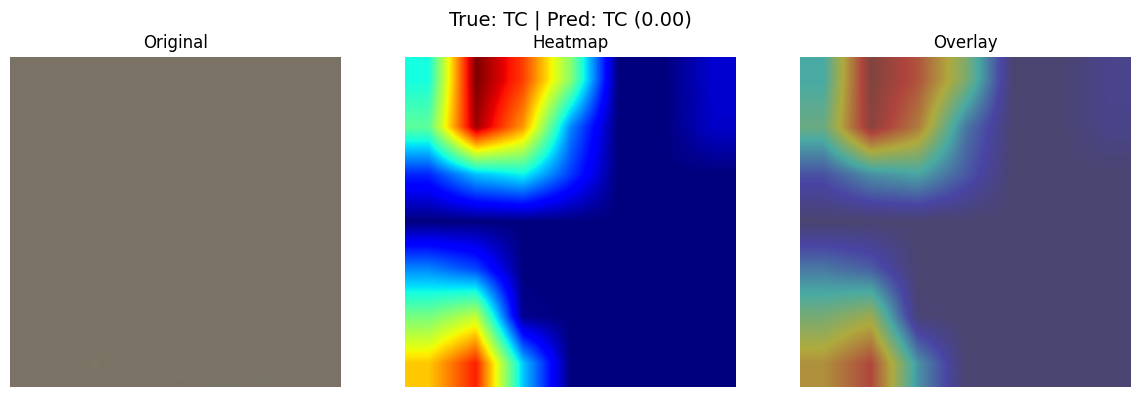

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


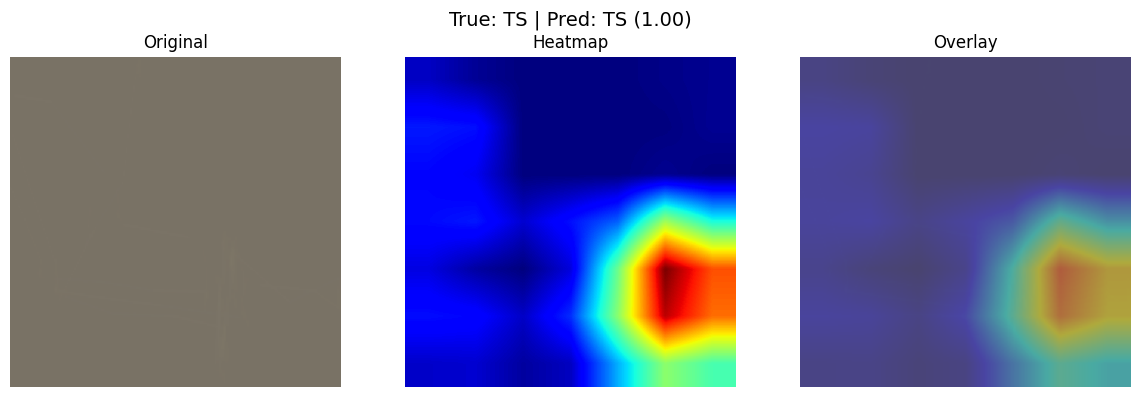

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


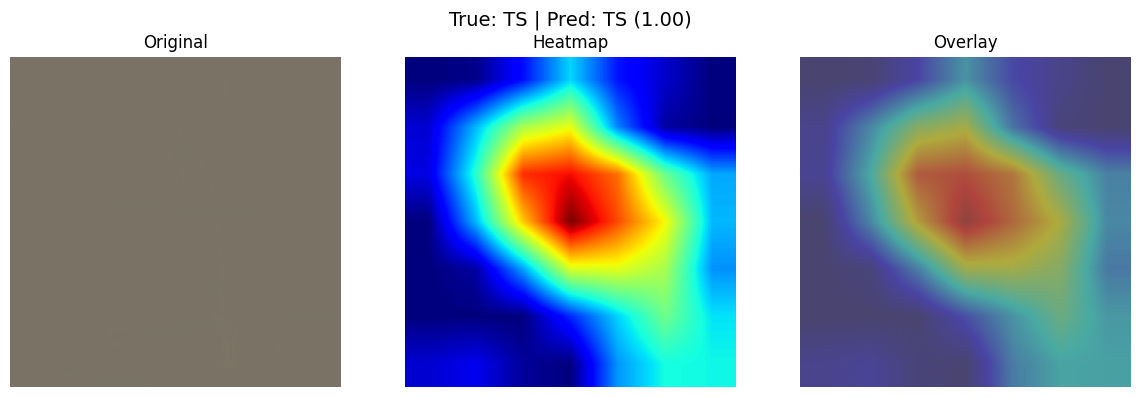

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


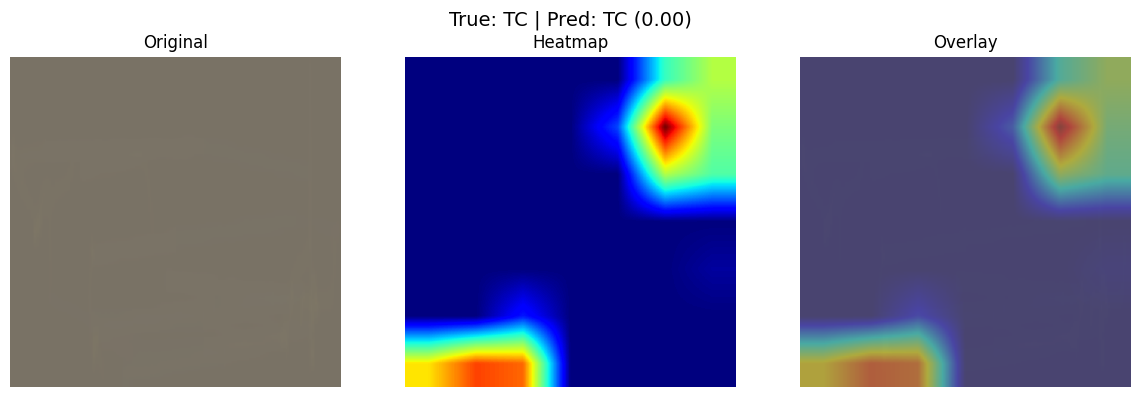

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


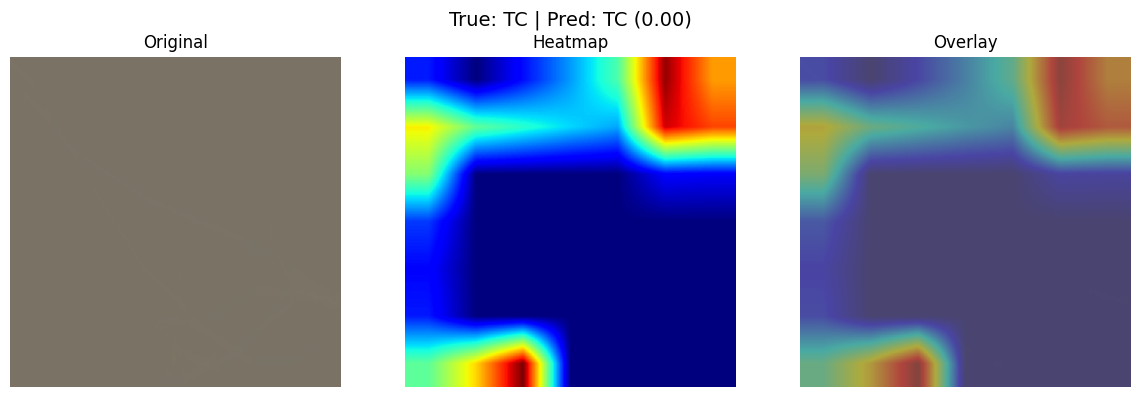

In [ ]:
display_gradcam_batch(X_test, y_test, model, num_samples=5)

In [ ]:
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def display_gradcam_batch(X_data, y_data, model, num_samples=5, last_conv_layer='conv5_block16_2_conv'):
    indices = random.sample(range(len(X_data)), num_samples)

    for idx in indices:
        img = X_data[idx]
        label = y_data[idx]
        img_input = np.expand_dims(img, axis=0)  # Add batch dimension

        # Generate Grad-CAM heatmap
        heatmap = make_gradcam_heatmap(img_input, model, last_conv_layer)

        # Debugging step: Show the heatmap without the original image
        plt.figure(figsize=(6, 6))
        plt.imshow(heatmap, cmap='jet')
        plt.title("Heatmap Only")
        plt.axis('off')
        plt.show()

        # Debugging step: Directly show the original image without any processing
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title("Original Image")
        plt.axis('off')
        plt.show()

        # Reconstruct original image (if necessary for your preprocessing)
        orig = img.copy()

        # Ensure the image is in RGB format for display (if originally in BGR)
        orig = orig[..., ::-1]  # Convert from BGR to RGB

        # Debugging: Check if the image is in the right range and format
        print(f"Image shape: {orig.shape}, min: {orig.min()}, max: {orig.max()}")

        # Clip the values to ensure they are within the valid display range
        orig = np.clip(orig, 0, 255).astype('uint8')

        # Resize heatmap and overlay it
        heatmap_resized = cv2.resize(heatmap, (orig.shape[1], orig.shape[0]))
        heatmap_vis = np.uint8(255 * heatmap_resized)
        overlay = cv2.applyColorMap(heatmap_vis, cv2.COLORMAP_JET)
        overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)  # Convert to RGB for display
        superimposed = cv2.addWeighted(orig, 0.6, overlay, 0.4, 0)

        # Model prediction
        pred = model.predict(img_input)[0]  # Model prediction (assumes binary classification)

        # Predict class
        pred_class = 'TS' if pred >= 0.5 else 'TC'
        actual_class = 'TS' if label == 1 else 'TC'

        # Plotting
        plt.figure(figsize=(12, 4))
        plt.suptitle(f"True: {actual_class} | Pred: {pred_class} ({pred[0]:.2f})", fontsize=14)

        plt.subplot(1, 3, 1)
        plt.imshow(orig)
        plt.title("Original")
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.imshow(heatmap_resized, cmap='jet')
        plt.title("Heatmap")
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.imshow(superimposed)
        plt.title("Overlay")
        plt.axis('off')

        plt.tight_layout()
        plt.show()


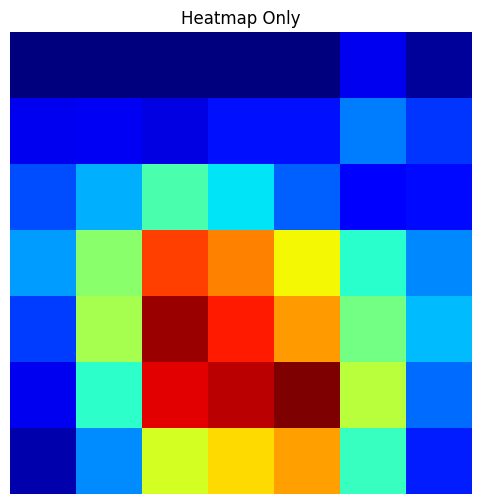

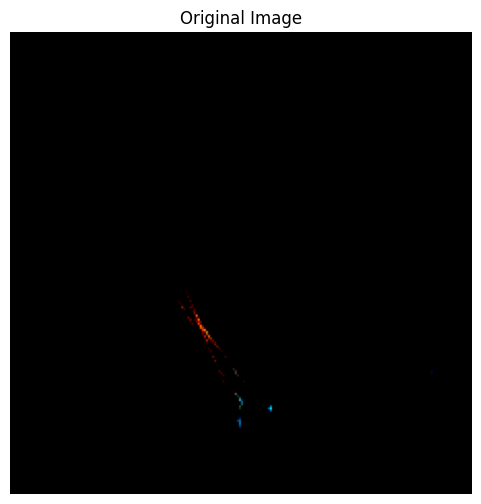

Image shape: (224, 224, 3), min: -2.1179039478302, max: 1.1236603260040283
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


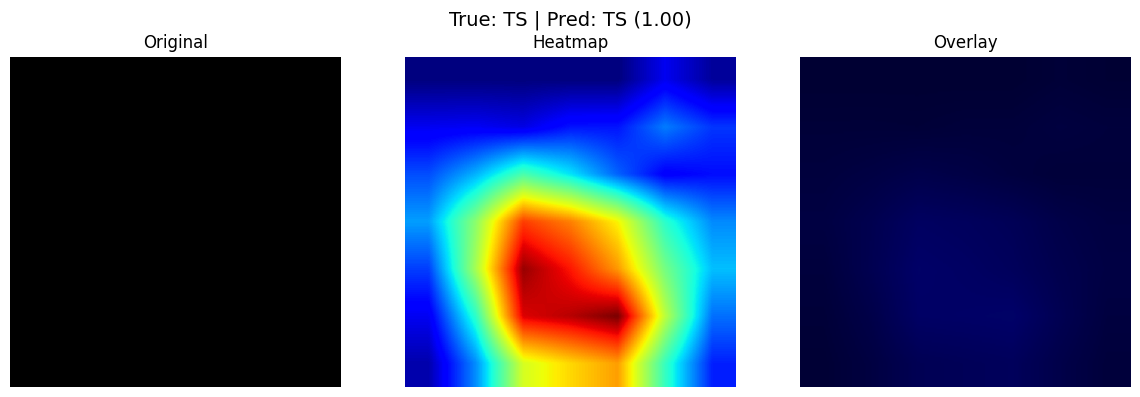

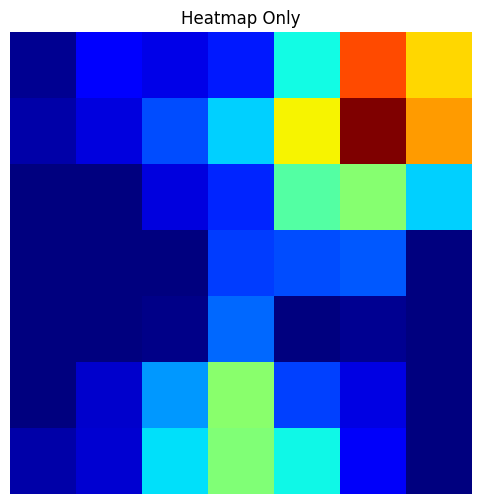

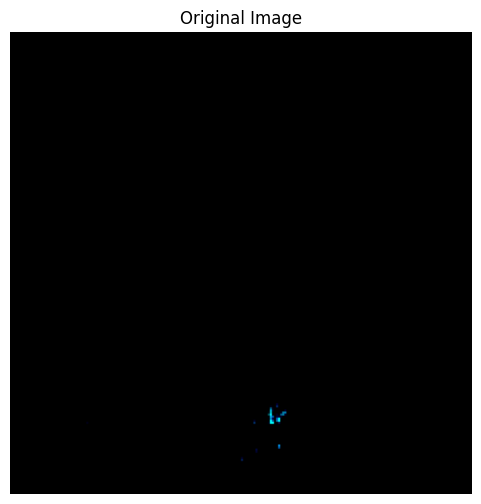

Image shape: (224, 224, 3), min: -2.1179039478302, max: 1.7162529230117798
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


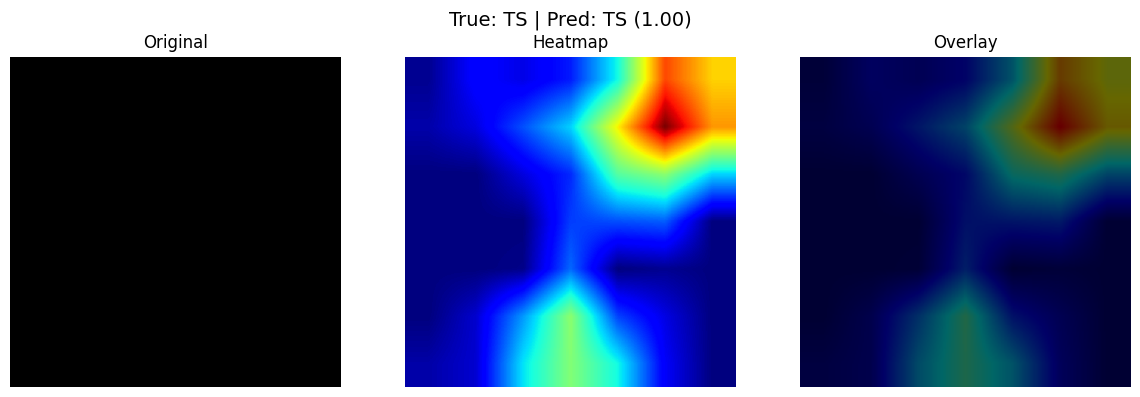

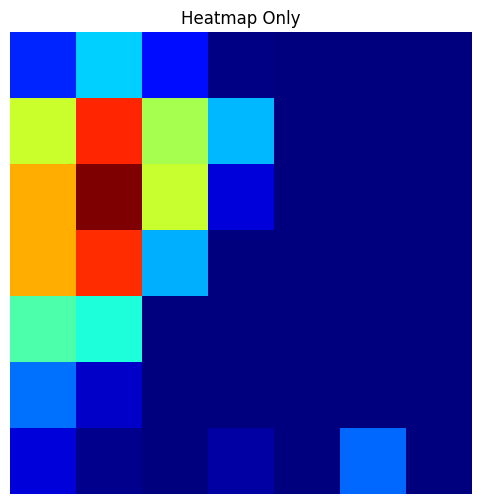

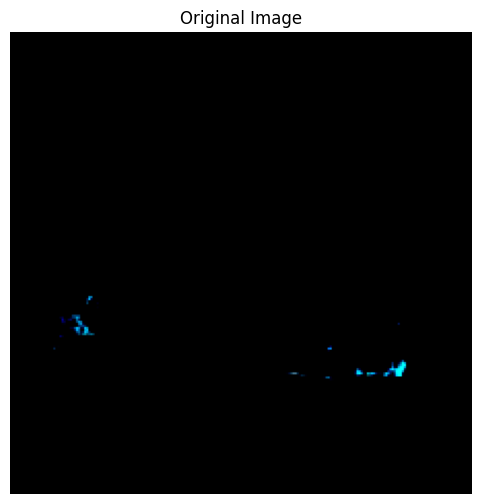

Image shape: (224, 224, 3), min: -2.1179039478302, max: 1.9079740047454834
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


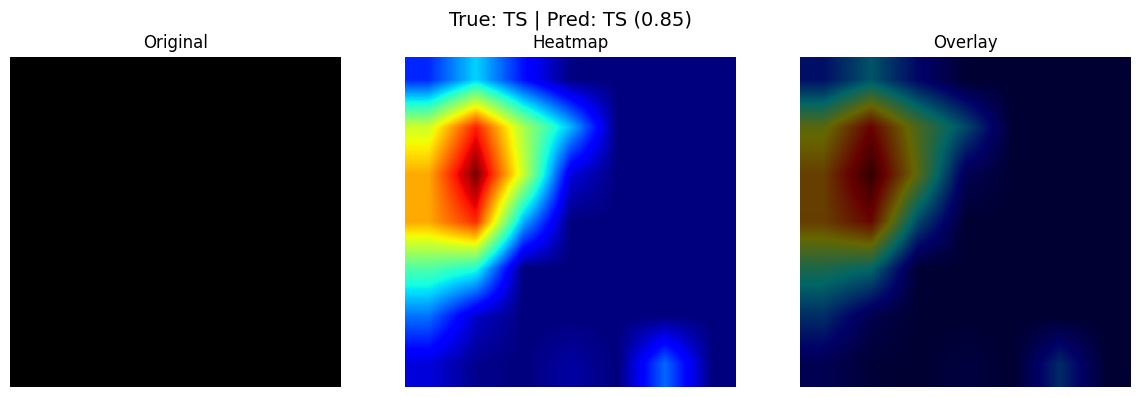

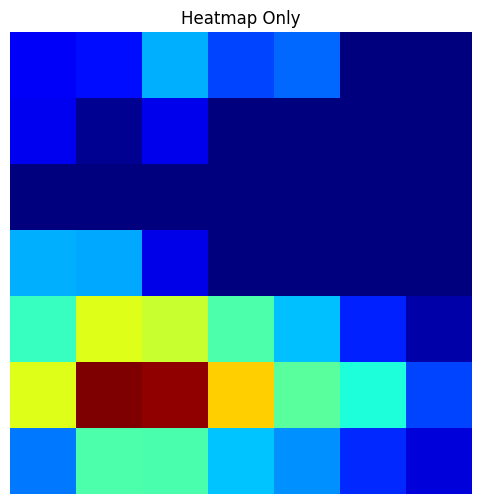

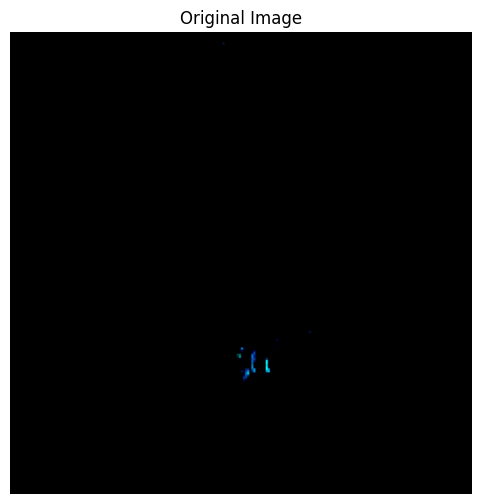

Image shape: (224, 224, 3), min: -2.1179039478302, max: 1.6639653444290161
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


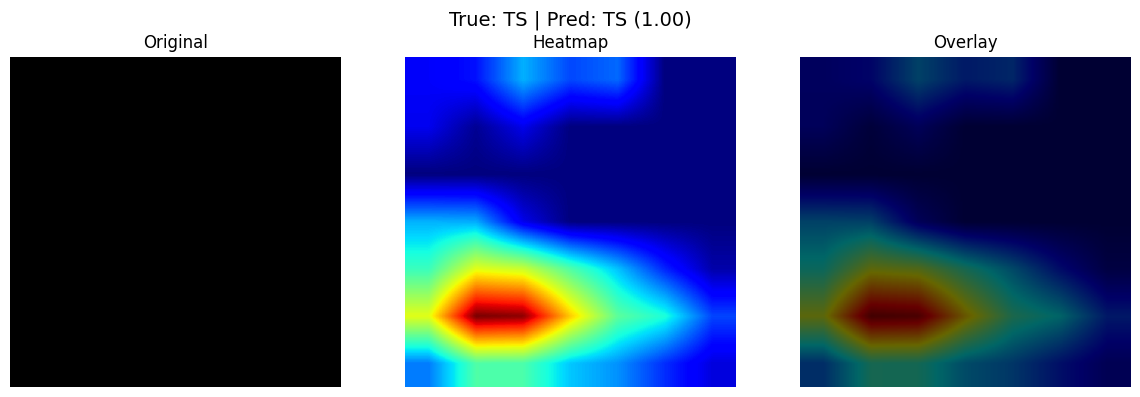

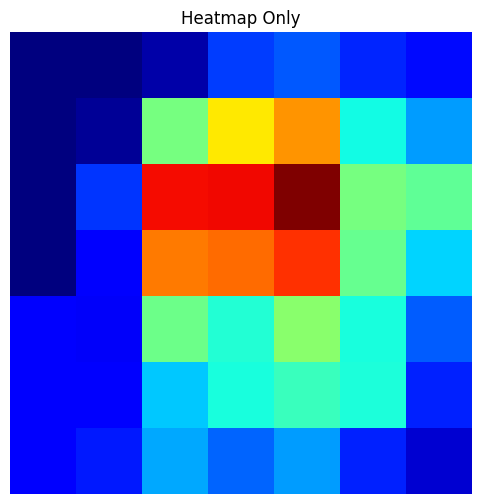

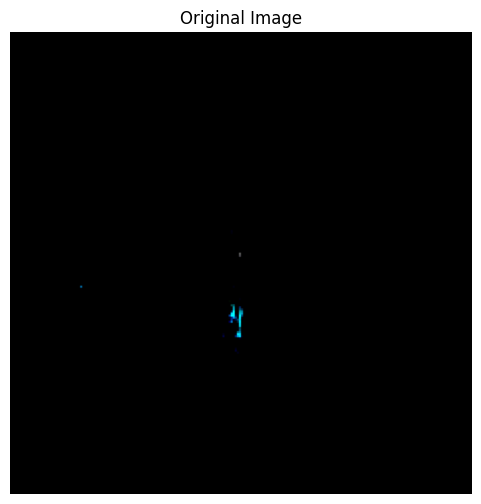

Image shape: (224, 224, 3), min: -2.1179039478302, max: 1.9254032373428345
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


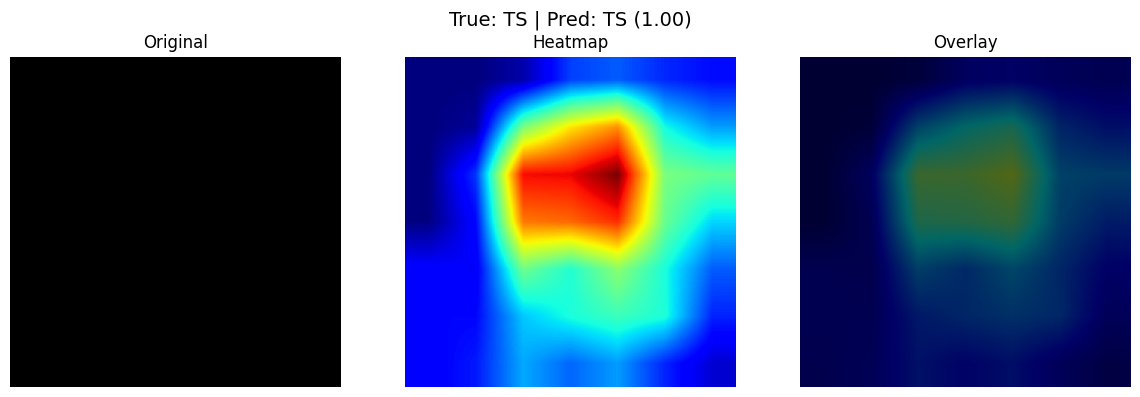

In [ ]:
display_gradcam_batch(X_test, y_test, model, num_samples=5)

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.densenet import preprocess_input

# Define your class mapping
class_names = {0: 'TC', 1: 'TS'}

# Grad-CAM function
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = np.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# Grad-CAM visualization function
def show_gradcam_on_image(
    cropped_img_path, original_img_path, model,
    last_conv_layer='conv5_block16_2_conv',
    class_names={0: 'TC', 1: 'TS'},
    true_class=None
):
    img = load_img(cropped_img_path, target_size=(224, 224))
    img_array = img_to_array(img)
    processed_img = preprocess_input(np.expand_dims(img_array, axis=0))

    original_img = load_img(original_img_path)
    original_display = img_to_array(original_img).astype('uint8')

    pred_prob = model.predict(processed_img, verbose=0)[0][0]
    pred_class = int(pred_prob >= 0.5)
    pred_label = class_names[pred_class]
    actual_label = true_class if true_class else "Unknown"
    pred_text = f"Predicted: {pred_label} ({pred_prob:.2f})\nActual: {actual_label}"

    heatmap = make_gradcam_heatmap(processed_img, model, last_conv_layer)
    heatmap_resized = cv2.resize(heatmap, (img_array.shape[1], img_array.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(img_array.astype('uint8'), 0.6, heatmap_colored, 0.4, 0)
    superimposed_rgb = cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(15, 6))
    for idx, (image, title) in enumerate(zip(
        [original_display, heatmap_resized, superimposed_rgb],
        ['Original Image (Cropped)', 'Grad-CAM Heatmap', 'Superimposed + Prediction']
    )):
        plt.subplot(1, 3, idx + 1)
        if idx == 1:
            plt.imshow(image, cmap='jet')
        else:
            plt.imshow(image.astype('uint8'))
        plt.title(f"{title}\n{pred_text if idx == 0 else ''}", fontsize=11)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Load and process 5 random images from TS and TC folders
def process_random_images_from_classes(model, n=5):
    tc_dir = "/kaggle/working/Dataset/TC/Cropped/"
    ts_dir = "/kaggle/working/Dataset/TS/Cropped/"

    image_list = []
    for class_name, folder in zip(['TC', 'TS'], [tc_dir, ts_dir]):
        files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        for f in files:
            image_list.append({
                "path": os.path.join(folder, f),
                "label": class_name
            })

    selected = random.sample(image_list, min(n, len(image_list)))

    for item in selected:
        cropped_path = item["path"]
        true_label = item["label"]

        # Assume original and cropped have same name but are in different directories
        original_path = cropped_path.replace("/Cropped/")  # change if needed
        show_gradcam_on_image(
            cropped_img_path=cropped_path,
            original_img_path=original_path,
            model=model,
            last_conv_layer='conv5_block16_2_conv',
            class_names=class_names,
            true_class=true_label
        )


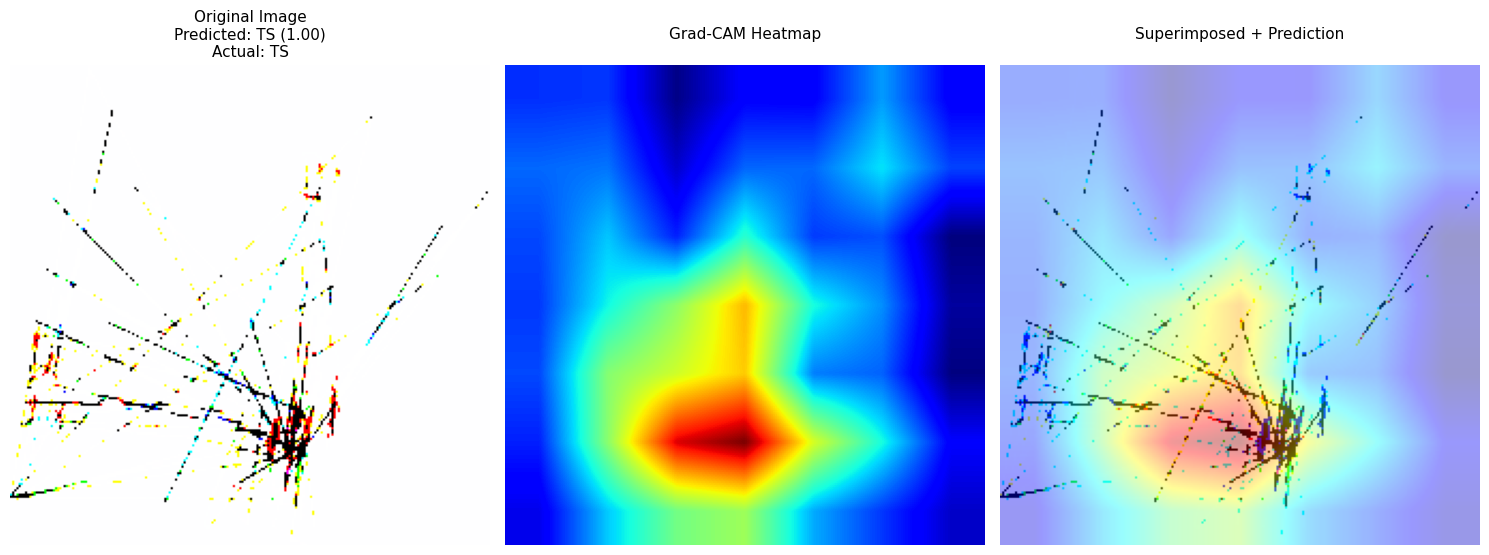

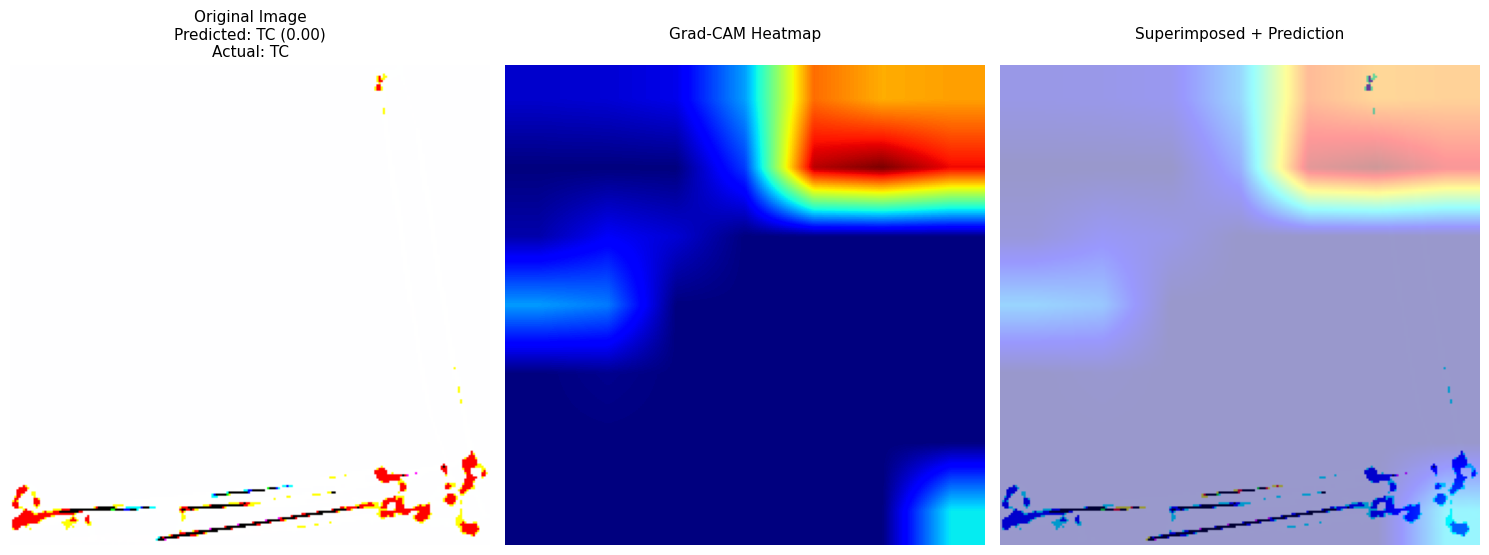

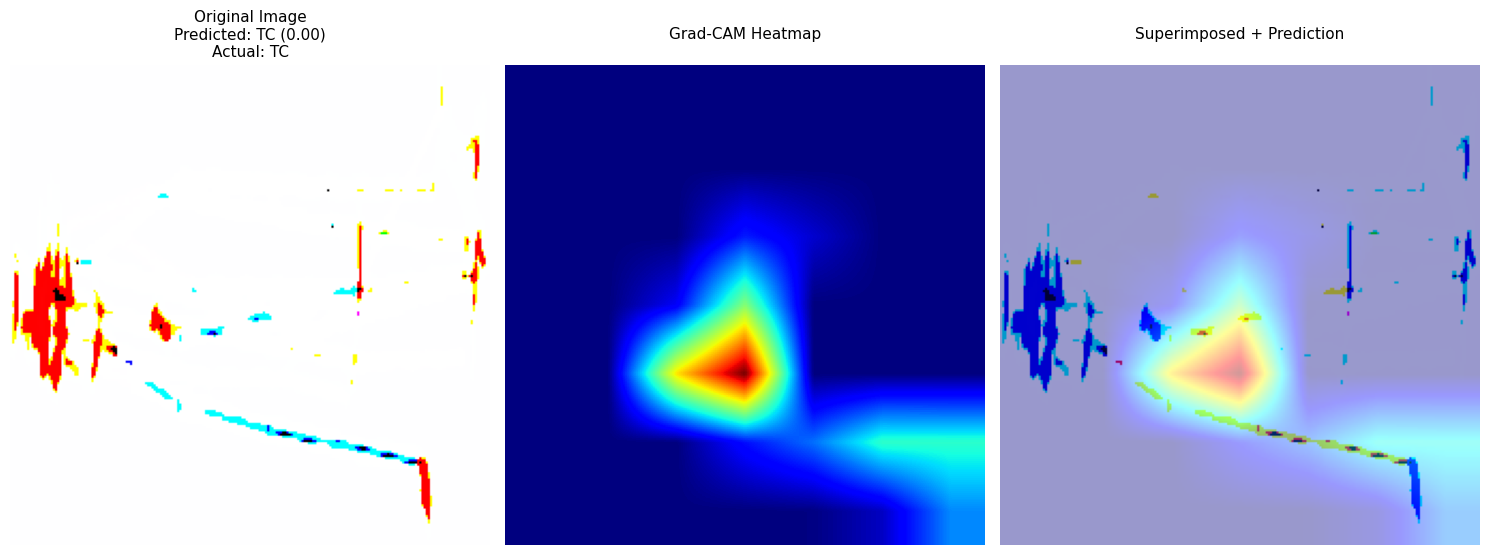

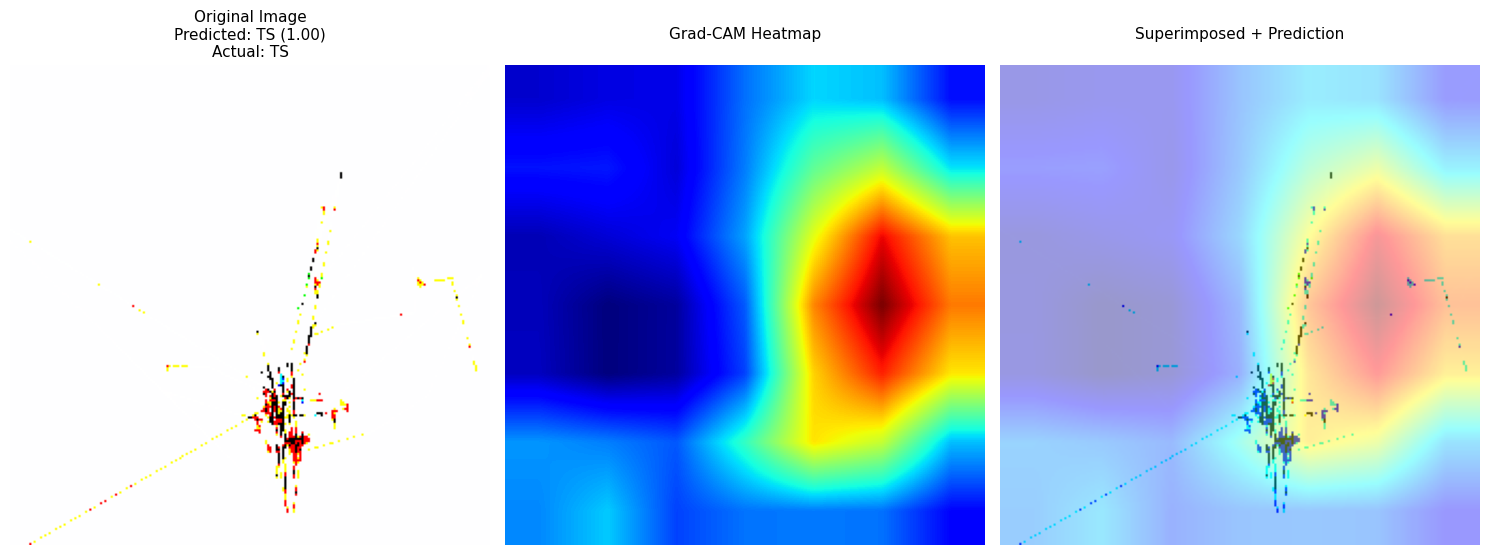

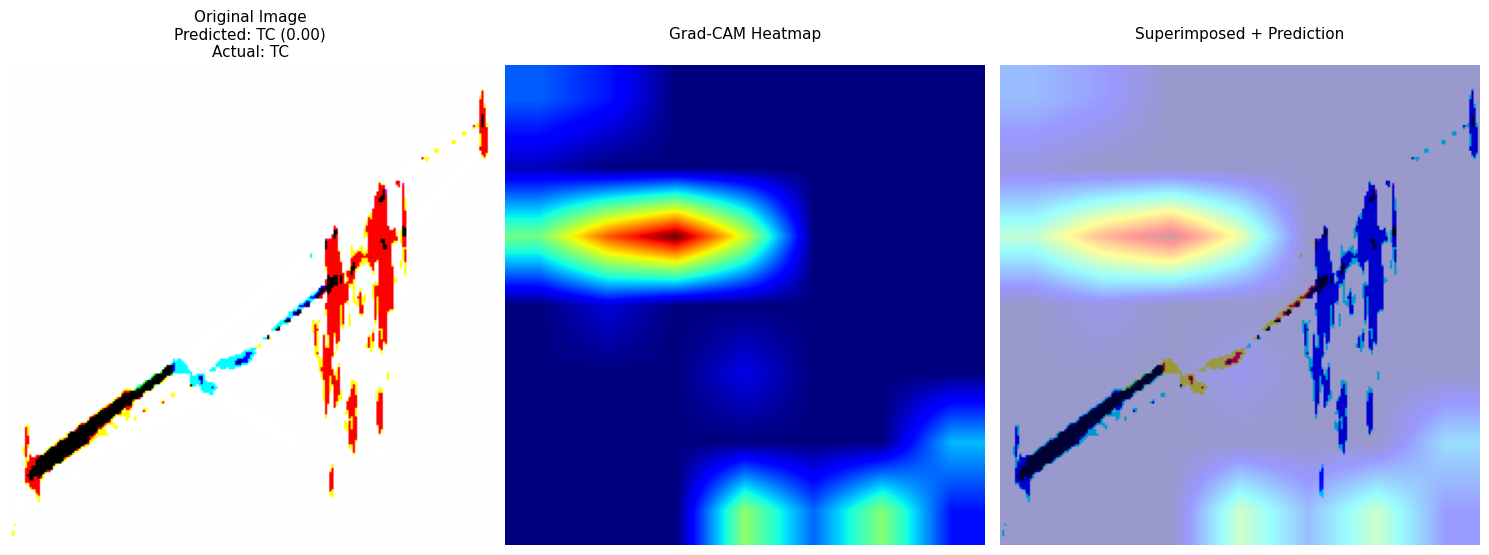

In [ ]:
from tensorflow.keras.models import load_model

# Load trained DenseNet121 model
#model = load_model('/kaggle/working/my_densenet_model.h5')

# Visualize Grad-CAMs
process_random_images(model, n=5)



In [ ]:
def show_gradcam_on_image(
    img_path, model,
    last_conv_layer='conv5_block16_2_conv',
    class_names={0: 'TC', 1: 'TS'},
    true_class=None
):
    # Load image
    img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img)
    input_tensor = preprocess_input(np.expand_dims(img_array.copy(), axis=0))
    display_img = img_array.astype('uint8')

    # Predict
    pred_prob = model.predict(input_tensor, verbose=0)[0][0]
    pred_class = int(pred_prob >= 0.5)
    pred_label = class_names[pred_class]
    actual_label = true_class if true_class else "Unknown"
    pred_text = f"Predicted: {pred_label} ({pred_prob:.2f})\nActual: {actual_label}"

    # Grad-CAM heatmap
    heatmap = make_gradcam_heatmap(input_tensor, model, last_conv_layer)

    # Normalize heatmap to [0,1] range more carefully
    heatmap = np.uint8(255 * (heatmap - np.min(heatmap)) / (np.max(heatmap) - np.min(heatmap) + 1e-8))
    heatmap_resized = cv2.resize(heatmap, (img_array.shape[1], img_array.shape[0]))
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

    # Ensure both image and heatmap are uint8 and same size
    superimposed_img = cv2.addWeighted(display_img.astype('uint8'), 0.8, heatmap_colored, 0.4, 0)
    superimposed_rgb = cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB)

    # Plot results
    plt.figure(figsize=(15, 6))
    for idx, (image, title) in enumerate(zip(
        [display_img, heatmap_colored, superimposed_rgb],
        ['Original Image', 'Grad-CAM Heatmap', 'Superimposed + Prediction']
    )):
        plt.subplot(1, 3, idx + 1)
        plt.imshow(image if idx != 1 else image, cmap='jet' if idx == 1 else None)
        plt.title(f"{title}\n{pred_text if idx == 0 else ''}", fontsize=11)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


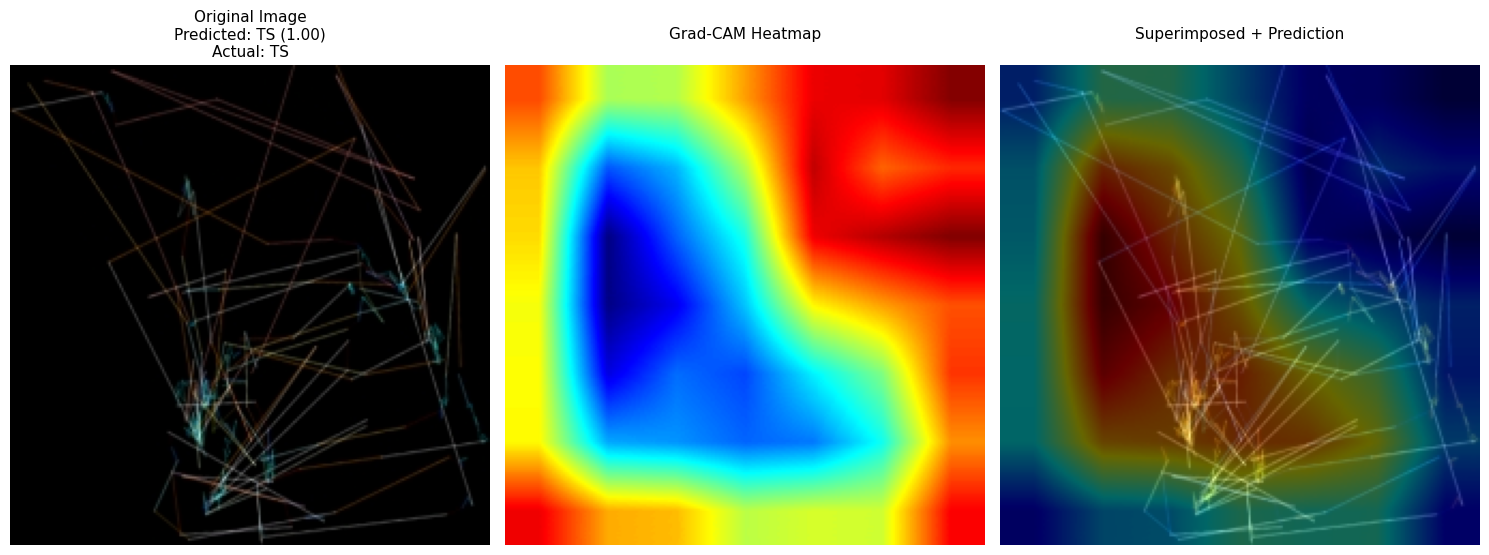

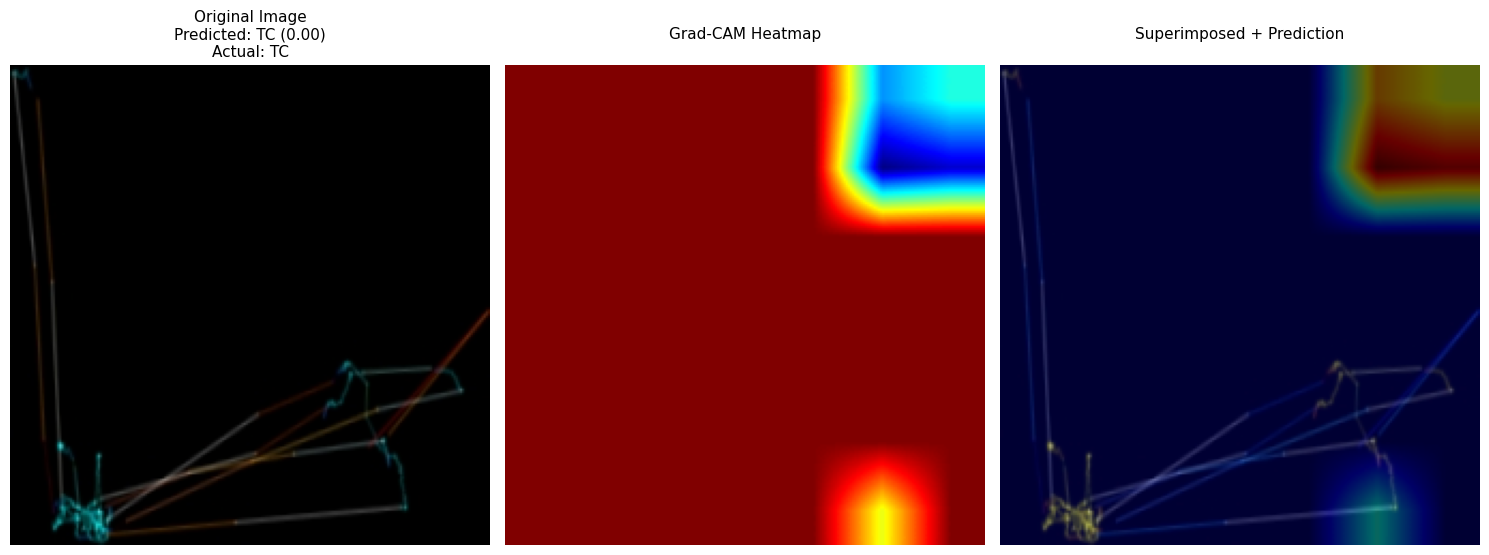

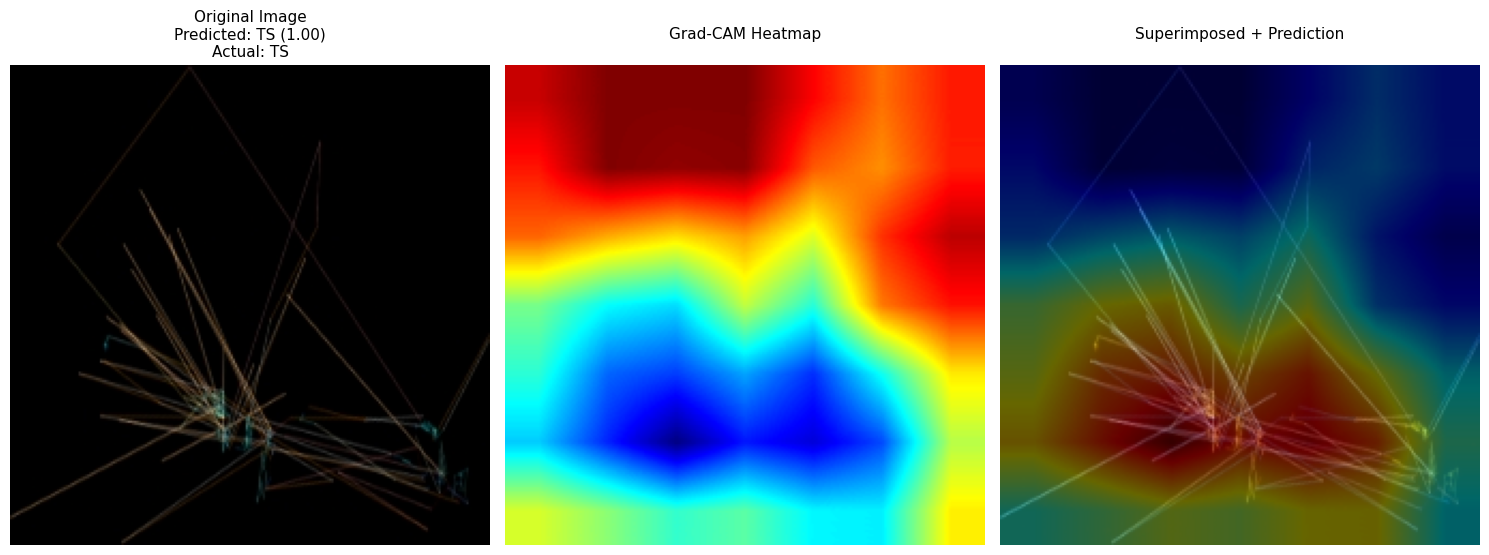

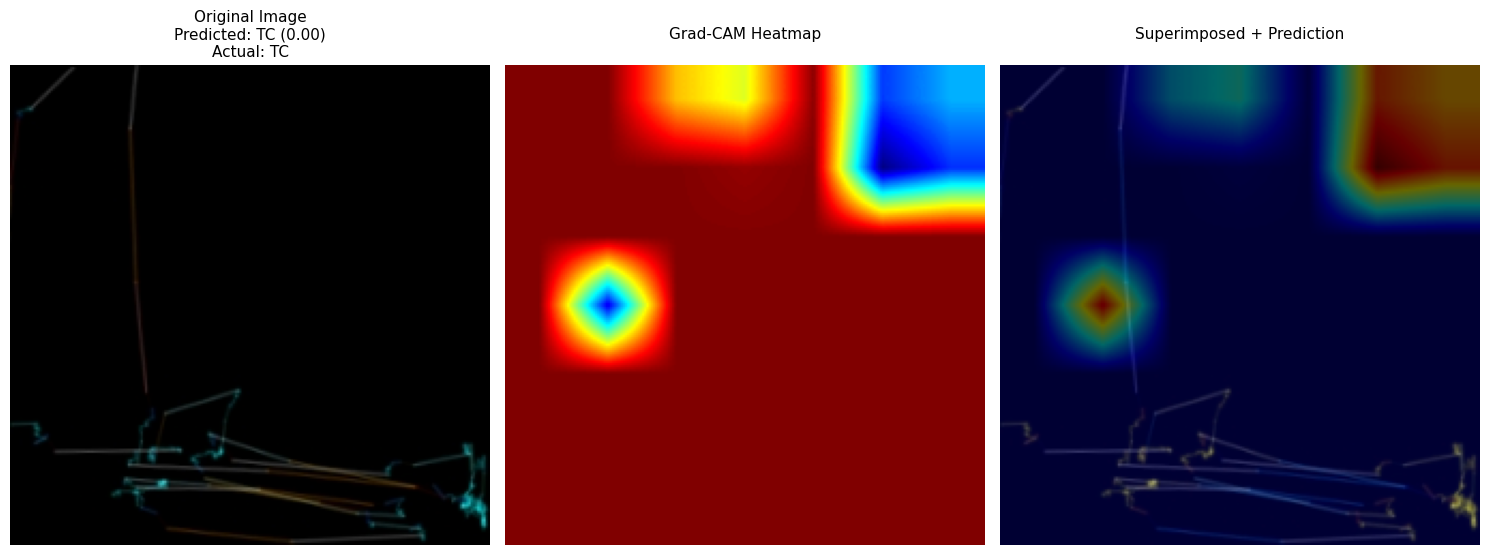

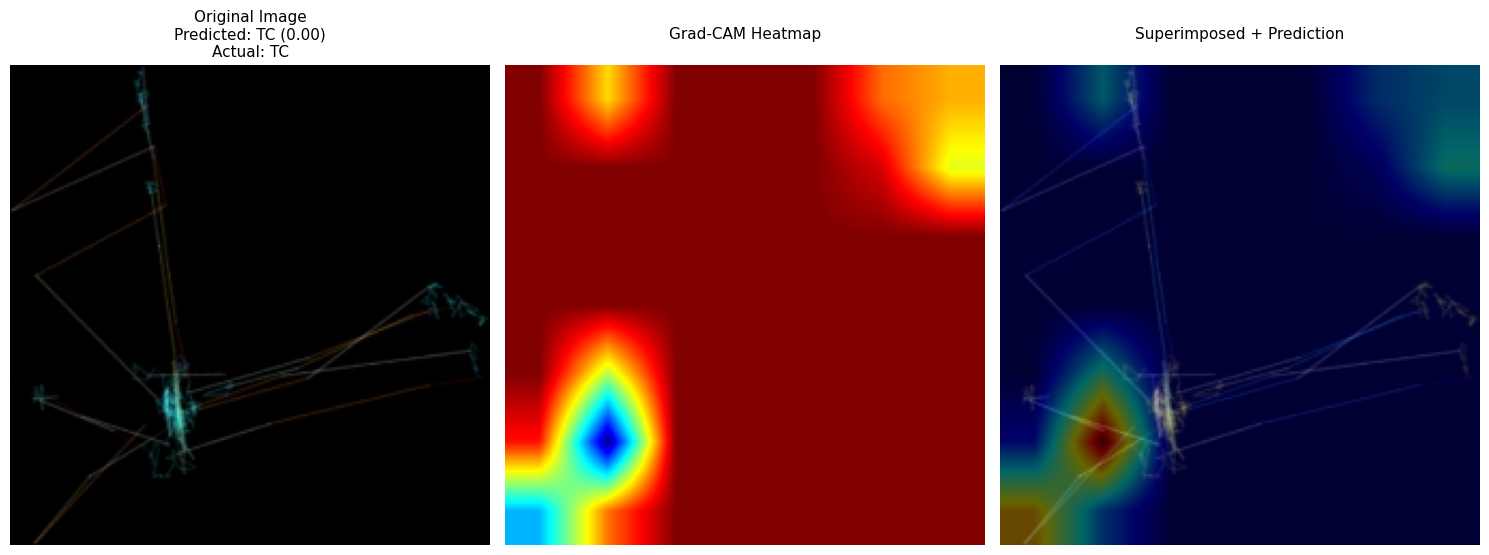

In [ ]:
# Load trained DenseNet121 model
#model = load_model('/kaggle/working/my_densenet_model.h5')

# Visualize Grad-CAMs
process_random_images(model, n=5)
